<a href="https://colab.research.google.com/github/jldz9/InSARHub/blob/tutorial/insarhub_tutorial_v0.2.4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# InSARHub Tutorial
`⚠️ Note: This tutorial is for InSARHub v0.2.4`


[![PyPI](https://img.shields.io/pypi/v/insarhub)](https://pypi.org/project/insarhub/)
[![GitHub](https://img.shields.io/badge/GitHub-InSARHub-blue)](https://github.com/jldz9/InSARHub)

InSARHub is an end-to-end InSAR processing framework that wraps satellite data search, cloud-based processing (HyP3), and time-series analysis (MintPy) into a single unified interface.

This notebook covers:
1. **Installation**
2. **Account Setup**
3. **Python API**
4. **CLI Usage**
5. **Web UI (Frontend)**

---
> **Study area**: Parowan Valley, Utah — track 100, frame 466

## 1. Installation

**<font color='Orange'>This step will set up the program environment. This may take several minutes. A runtime restart might be required after installation.</font>**

**<font color='red'>Red error is due to swap of Numpy version and can be ignored</font>**


In [ ]:
!pip install insarhub

In [ ]:
!insarhub --version

In [ ]:
from pathlib import Path
API_workdir = '/content/API'
CLI_workdir ='/content/CLI'
GUI_workdir = '/content/GUI'

for dir in [API_workdir, CLI_workdir, GUI_workdir]:
  Path(dir).mkdir(parents=True, exist_ok=True)

## 2. Account Setup

InSARHub requires free accounts at:

| Service | Purpose | Sign up |
|---------|---------|--------|
| NASA Earthdata | Scene search, DEM, HyP3 submission | [urs.earthdata.nasa.gov](https://urs.earthdata.nasa.gov) |
| Copernicus Climate Data Store (CDS) | ERA5 troposphere correction | [cds.climate.copernicus.eu](https://cds.climate.copernicus.eu) |

Run the cells below to save credentials.

In [ ]:
Earthdata_Username = 'Your Earthdata Username'
Earthdata_Password = 'Your Earthdata Password'

Get your CDS API Key [HERE](https://cds.climate.copernicus.eu/profile)

In [ ]:
CCDS_API_Key = 'Your CDS API TOKEN'

In [ ]:
from pathlib import Path
import os
netrc_path = Path.home() / ".netrc"
# Create netrc file
rc_path = Path.home() / ".cdsapirc"
# Write credentials to ~/.netrc
with open(netrc_path, "w") as f:
    f.write(f"""machine urs.earthdata.nasa.gov
login {Earthdata_Username.strip()}
password {Earthdata_Password.strip()}
""")

with open(rc_path, "w") as f:
    f.write(f"""url: https://cds.climate.copernicus.eu/api
key: {CCDS_API_Key.strip()}
""")


---
## 3. Python API

InSARHub is designed with three config-based main modules: **Downloader**, **Processor**, and **Analyzer** to cover the entire InSAR processing workflow:

**Set AOI** --> **Searching** --> **Result Filtering** --> **Interferogram** --> **Time-series Analysis**

In [ ]:
from insarhub import Downloader, Processor, Analyzer

# List all available implementations
print('Downloaders:', Downloader.available())
print('Processors: ', Processor.available())
print('Analyzers:  ', Analyzer.available())

### 3.1 Search Sentinel-1 Scenes

InSARHub allows defining the AOI using bounding box, shapefiles, or WKT:

In [ ]:
AOI = [-113.05, 37.74, -112.68, 38.00] #Bounding box
AOI = 'path/to/your/shapefile.shp' #Shapefiles
AOI = 'POLYGON((-113.05 37.74, -113.05 38.00, -112.68 38.00, -112.68 37.74, -113.05 37.74))' #WKT

In [ ]:
# Create a Sentinel-1 SLC downloader
# AOI: [west, south, east, north] in WGS84 degrees
AOI = [-113.05, 37.74, -112.68, 38.00]
s1 = Downloader.create(
    'S1_SLC',
    intersectsWith=AOI,
    workdir=API_workdir
)

results = s1.search()
s1.summary()

Your AOI probably spans multiple scenes. To view the search result footprints, you can use:

In [ ]:
s1.footprint()

The program identified 18 potential stacks (14 ascending, 4 descending). We can narrowed the dataset to the descending track Path 100, Frame 466 in year 2020 by:

In [ ]:
filter_results = s1.filter(path_frame=(100,466), start='2020-01-01', end='2020-12-31')

Check back the footprint and summary:

In [ ]:
s1.footprint()
s1.summary()

### 3.2 Select Interferometric Pairs

In [ ]:
from insarhub.utils import select_pairs, plot_pair_network
pair_stacks, B ,pb= select_pairs(filter_results, max_degree=5) # We set the maximum connections to 5 to reduce interferograms
fig = plot_pair_network(pair_stacks, B, pb)

### 3.3 Submit to HyP3 for Processing



After locating SAR scene stack(s), the next step is to generate unwrapped interferograms in preparation for the time-series analysis. InSARHub currently supports:

- **HyP3**: Use the [HyP3 platform](https://hyp3-docs.asf.alaska.edu/) provided by ASF to run the interferometric processing in the cloud and download the resulting interferograms.

In [ ]:
from insarhub import Processor
for (path, frame), pairs in pair_stacks.items():
    processor = Processor.create('Hyp3_InSAR', pairs=pairs, workdir=API_workdir)
    batch = processor.submit()
    processor.save()

This process will generate hyp3_jobs.json under your work directory, which contains the jobID submitted to the hyp3 server, the processing will take roughly 30 mins for 100 interferograms depends on the ASF server load.

You may download the job file to check back the progress later:

In [ ]:
from google.colab import files
files.download('/content/API/hyp3_jobs.json')

### 3.4 Check HyP3 Processing Status and Download
To check the job processing status
- If you still under same session:

In [ ]:
batchs = processor.refresh()

 - If you starts a new session and need to read from saved job file

In [ ]:
import os
from google.colab import files
uploaded = files.upload()
for filename, content in uploaded.items():
    dest = f'/content/API/{filename}'
    with open(dest, 'wb') as f:
        f.write(content)
    os.remove(f'/content/{filename}')
    print(f"Saved file to {dest}")
from insarhub import Processor
processor = Processor.create('Hyp3_InSAR', saved_job_path=f'/content/API/{filename}', workdir=f'/content/API')
batchs = processor.refresh()

To download completed jobs from Hyp3 Server

In [ ]:
processor.download()

### 3.5 Retry failed Hyp3 jobs

Sometime Hyp3 Job will fail when server load is high, download sucessed job first and then use .retry() to resubmit failed jobs. It will create a new job file named `hyp3_retry_jobs_YYYYMMDDtHHMMSS.json`

In [ ]:
processor.retry() # Only when you have failed jobs
processor.refresh()

In [ ]:
# Download retry job file
from pathlib import Path
from google.colab import files
retry_job = Path('/content/API').glob('hyp3_retry_jobs_*.json')
for file in retry_job:
    files.download(file)

In [ ]:
# Upload retry job file to check retry status if you start a new session
import os
from google.colab import files
uploaded = files.upload()
for filename, content in uploaded.items():
    dest = f'/content/API/{filename}'
    with open(dest, 'wb') as f:
        f.write(content)
    os.remove(f'/content/{filename}')
    print(f"Saved file to {dest}")
from insarhub import Processor
processor = Processor.create('Hyp3_InSAR', saved_job_path=f'/content/API/{filename}', workdir=f'/content/API')
batchs = processor.refresh()

In [ ]:
# Download retried jobs
processor.download()

For a quick demonstration of time-series analysis, it is recommended to use prepared file below:

In [ ]:
!gdown --fuzzy "https://drive.google.com/file/d/1Tef1kLDKEPA11pNt8FhgLRM4aSnwOMTu/view?usp=sharing"
!gdown --fuzzy "https://drive.google.com/file/d/1NvCrDArsNU8zE82pG39vej3oaoXfZVFy/view?usp=sharing"
!unzip clipped.zip -d /content/API/
!unzip ERA5.zip -d /content/API

### 3.6 Time-Series Analysis with MintPy

After generating all unwrapped interferograms, time-series analysis is recommended for long term deformation monitoring. InSARHub currently supports:

- MintPy: an open-source Python package for InSAR time-series analysis.

In [ ]:
from insarhub import Analyzer
hyp3_sbas = Analyzer.create('Hyp3_SBAS', workdir=API_workdir, troposphericDelay_weatherDir='/content/API', reference_lalo='37.8412415,-112.8293839')
hyp3_sbas.prep_data()
hyp3_sbas.run()

In [ ]:
# Or run specific steps only
analyzer.run(steps=[
    'load_data',
    'reference_point',
    'invert_network',
    'correct_troposphere',  # requires CDS token
    'velocity',
    'geocode',
])

### 3.7 Visualize data

- To view the mean velocity map

In [ ]:
import rasterio
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline
from insarhub.utils import h5_to_raster

h5_to_raster('/content/API/velocity.h5')
raster_path = '/content/API/velocity_velocity.tif'

with rasterio.open(raster_path) as src:
    data = src.read(1)

nodata_value = -9999
data[data == nodata_value] = np.nan

vmin, vmax = np.nanpercentile(data, [0.1, 99.9])

# Create figure with proper layout
fig, ax = plt.subplots(figsize=(12, 10))

# Set bad values (NaN) to appear as light gray
cmap = plt.cm.turbo
cmap.set_bad(color='lightgray', alpha=0.3)

# Plot the data
im = ax.imshow(data, cmap=cmap, vmin=vmin, vmax=vmax, interpolation='bilinear')

# Add colorbar on the right
cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Velocity (m/year)', fontsize=12, rotation=270, labelpad=20)
cbar.ax.tick_params(labelsize=10)

# Styling
ax.set_title('InSAR Velocity Map', fontsize=16, fontweight='bold', pad=15)
ax.axis('off')

plt.tight_layout()
plt.show()

- To view the time series of specific location

In [ ]:
from ipywidgets import interact, IntSlider
import h5py
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime
import rasterio

# Read timeseries data
with h5py.File('/content/API/timeseries_ERA5_ramp_demErr.h5', 'r') as f:
    timeseries = f['timeseries'][:]
    dates = f['date'][:]

date_list = [datetime.strptime(d.decode() if isinstance(d, bytes) else str(d), '%Y%m%d')
             for d in dates]
timeseries[timeseries == -9999] = np.nan

# Read velocity map
with rasterio.open('/content/API/velocity_velocity.tif') as src:
    velocity = src.read(1)

velocity[velocity == -9999] = np.nan

# Set your custom default values here
DEFAULT_X = 313  # Change this to your desired X pixel
DEFAULT_Y = 318  # Change this to your desired Y pixel

@interact(
    x=IntSlider(
        min=0,
        max=timeseries.shape[2]-1,
        value=DEFAULT_X,
        description='X pixel:'
    ),
    y=IntSlider(
        min=0,
        max=timeseries.shape[1]-1,
        value=DEFAULT_Y,
        description='Y pixel:'
    )
)
def plot_at_pixel(x, y):
    ts = timeseries[:, y, x]

    # Make timeseries start from 0 (relative to first date)
    ts_normalized = ts - ts[0]

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # Timeseries
    axes[0].plot(date_list, ts_normalized, 'o-', linewidth=2.5, markersize=7,
                 color='steelblue', markeredgecolor='navy')
    axes[0].axhline(y=0, color='red', linestyle='--', alpha=0.5, linewidth=2)
    axes[0].grid(True, alpha=0.3)
    axes[0].set_xlabel('Date', fontsize=12, fontweight='semibold')
    axes[0].set_ylabel('Displacement (m)', fontsize=12, fontweight='semibold')
    axes[0].set_title(f'Timeseries at pixel ({x}, {y})', fontsize=14, fontweight='bold')
    axes[0].tick_params(axis='x', rotation=45)

    # Add stats box
    mean_disp = np.nanmean(ts_normalized)
    std_disp = np.nanstd(ts_normalized)
    final_disp = ts_normalized[-1]
    axes[0].text(0.02, 0.98,
                f'Mean: {mean_disp:.2f} m\nStd: {std_disp:.2f} m\nFinal: {final_disp:.2f} m',
                transform=axes[0].transAxes, fontsize=10, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))

    # Velocity map
    vmin, vmax = np.nanpercentile(velocity, [0.1, 99.9])
    cmap = plt.cm.turbo
    cmap.set_bad(color='lightgray', alpha=0.3)

    im = axes[1].imshow(velocity, cmap=cmap, vmin=vmin, vmax=vmax, interpolation='bilinear')
    axes[1].plot(x, y, 'w*', markersize=22, markeredgewidth=2.5, markeredgecolor='black')
    axes[1].set_title('Mean Velocity Map', fontsize=14, fontweight='bold')
    axes[1].axis('off')

    cbar = plt.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)
    cbar.set_label('Velocity (m/year)', fontsize=11, rotation=270, labelpad=20)
    cbar.ax.tick_params(labelsize=10)

    plt.tight_layout()
    plt.show()

---
## 4. CLI Usage

All Python API functionality is also available via the command line. The full pipeline:

In [ ]:
# List available downloaders, processors, analyzers
!insarhub downloader --list-downloaders
!insarhub processor --list-processors
!insarhub analyzer --list-analyzers

In [ ]:
# Step 1: Search scenes and select pairs
!insarhub downloader -N S1_SLC \
    --AOI -113.05 37.74 -112.68 38.00 \
    --start 2020-01-01 --end 2020-12-31 \
    --stacks 100:466 \
    -w /content/CLI \
    --select-pairs --max-degree 5

In [ ]:
from IPython.display import Image, display
display(Image('/content/CLI/p100_f466/network_p100_f466.png'))

In [ ]:
# Step 2: Submit to HyP3 (dry run)
!insarhub processor -N Hyp3_InSAR -w /content/CLI submit --dry-run

Since we already have job file from API running, we just copy it under CLI workdirectory

In [ ]:
!cp /content/API/hyp3_jobs.json /content/CLI

In [ ]:
# Step 3: Refresh Hyp3 job status
!insarhub processor -N Hyp3_InSAR -w /content/CLI refresh


In [ ]:
# Step 4: Download completed results
!insarhub processor -N Hyp3_InSAR -w /content/CLI download

In [ ]:
# Step 5: Run SBAS time-series analysis
!insarhub analyzer -N Hyp3_SBAS -w /content/CLI run

---
## 5. Web UI (Frontend)

InSARHub includes an interactive map-based Web UI powered by FastAPI and React.

**Features:**
- Interactive AOI drawing on a map
- Scene search and pair selection
- HyP3 job submission and monitoring
- Velocity map overlay with hover values
- Pixel displacement time-series plot

### Launch in Colab with ngrok

Since Colab runs on a remote server, use [ngrok](https://ngrok.com) to expose the local port.

To use frontend under google colab, sign up for a free ngrok account at https://ngrok.com and get your authtoken

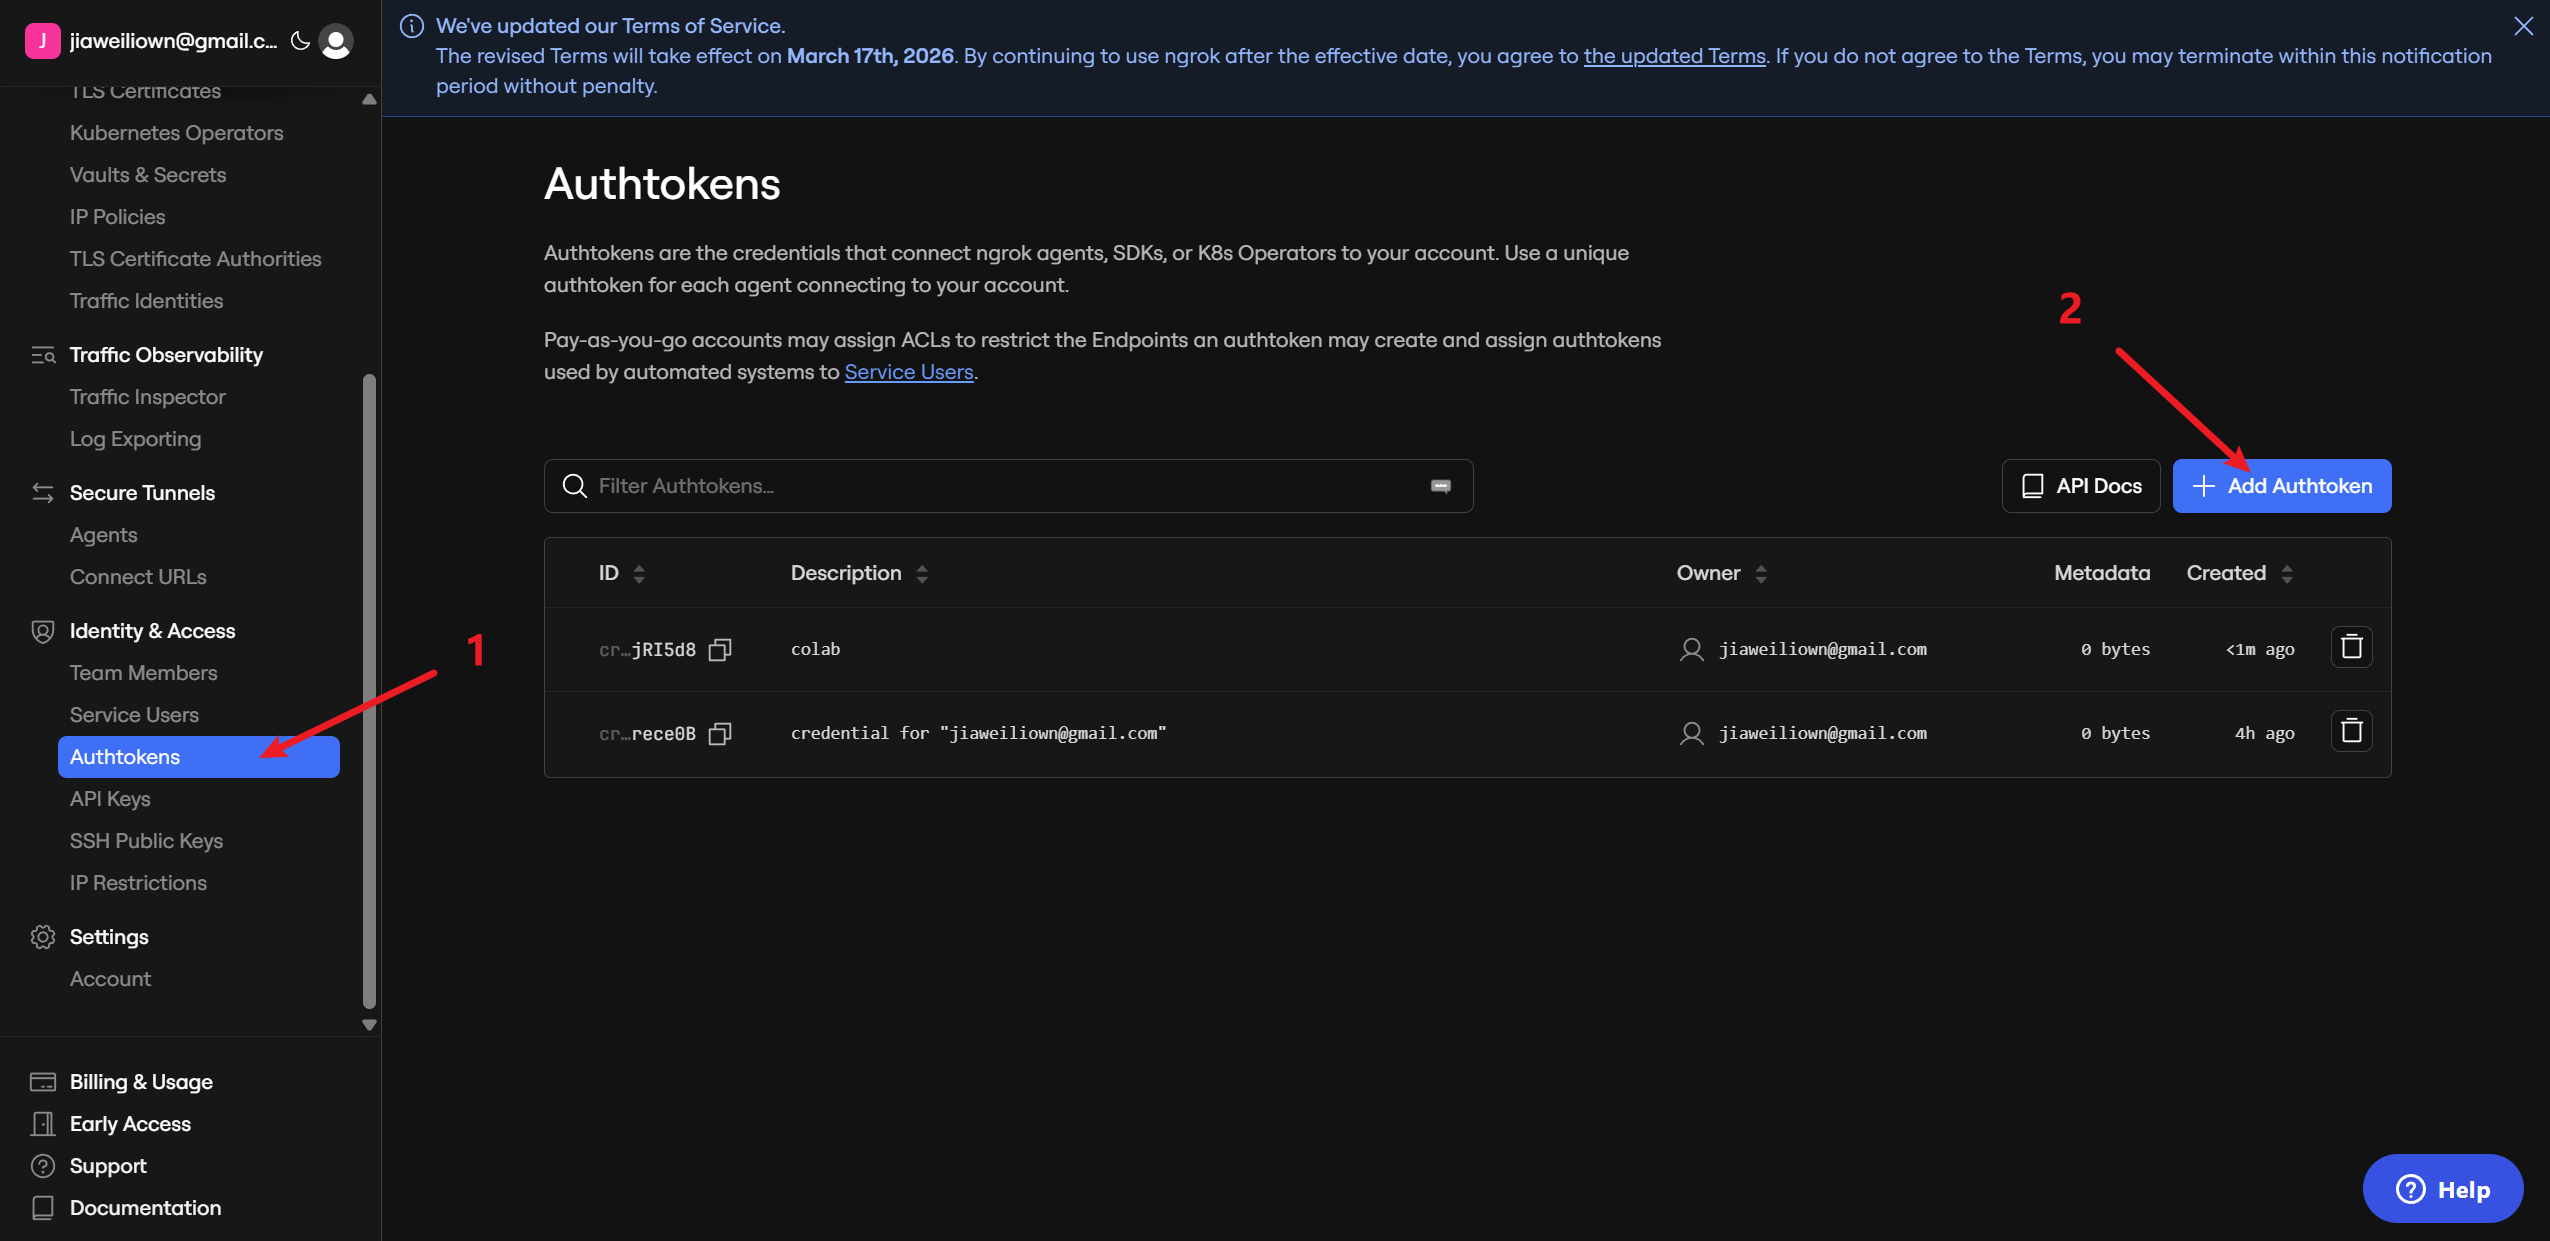

In [ ]:
ngrok_token ='Your Ngrok Authtoken'

In [ ]:
# Install pyngrok
!pip install pyngrok -q

In [ ]:

from pyngrok import ngrok

# Sign up for a free ngrok account at https://ngrok.com and get your auth token
ngrok.set_auth_token(ngrok_token)

In [ ]:
import subprocess, threading, time

# Start InSARHub web UI in background
proc = subprocess.Popen(
    ['insarhub-app','-w','/content/GUI', '--host', '0.0.0.0', '--port', '8000'],
    stdout=subprocess.DEVNULL,
    stderr=subprocess.DEVNULL,
)

# Wait for server to start
time.sleep(3)

# Create public tunnel
tunnel = ngrok.connect(8000)
print(f'InSARHub Web UI: {tunnel.public_url}')

Follow the [frontend manual](https://jldz9.github.io/InSARHub/v0.2.3/frontend/search/) for instruction to processing InSAR data using GUI

In [ ]:
# When done, stop the server and close tunnel
ngrok.disconnect(tunnel.public_url)
proc.terminate()
print('Server stopped.')

## Appendix: Local Installation

This section covers how to install InSARHub locally on **Windows**, **Linux**, and **macOS** using Anaconda.

### Prerequisites

Download and install [Miniconda](https://docs.conda.io/en/latest/miniconda.html) or [Anaconda](https://www.anaconda.com/download) for your platform.


After Miniconda or Anaconda installation, install InSARHub on:
### **Windows**

Search for **Anaconda Prompt** and run:
```bash
conda create -n insarhub
conda activate insarhub
conda install insarhub -c conda-forge
```

---

### **Linux**

Open a **Terminal** (Ctrl+Alt+T) and run:
```bash
conda create -n insarhub
conda activate insarhub
conda install insarhub -c conda-forge
```

---

### **macOS**
`⚠️ MacOS with apple silicon chip has not been tested`

Search for **Terminal** and run:
```bash
conda create -n insarhub
conda activate insarhub
conda install insarhub -c conda-forge
```

---
Verify installation:
```bash
insarhub --version
insarhub-app --version
```

### Launch the Web UI Locally

Once installed, activate the environment and launch:

```bash
conda activate insarhub
insarhub-app
```

Then open **http://127.0.0.1:8000** in your browser.

---
#### For more detailed instruction, check [InSARHub Documentation](https://jldz9.github.io/InSARHub/v0.2.3/)